In [13]:
# importando as bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [14]:
# carregando os dados
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28)


In [15]:
# adicionando o canal de cor
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28, 1)


In [16]:
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [18]:
# criando a CNN
i = Input(shape=x_train[0].shape)
x = Conv2D(32,  (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64,  (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)

In [19]:
# camada densa
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [20]:
# compilando e treinando
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15


2026-02-27 13:59:29.917021: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8092 - loss: 0.5145 - val_accuracy: 0.8397 - val_loss: 0.4119
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8687 - loss: 0.3520 - val_accuracy: 0.8699 - val_loss: 0.3503
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8857 - loss: 0.3037 - val_accuracy: 0.8857 - val_loss: 0.3197
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8985 - loss: 0.2713 - val_accuracy: 0.8933 - val_loss: 0.2972
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9062 - loss: 0.2478 - val_accuracy: 0.8920 - val_loss: 0.3003
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9147 - loss: 0.2270 - val_accuracy: 0.8971 - val_loss: 0.2958
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9201 - loss: 0.2079 - val_accuracy: 0.8980 - val_loss: 0.2932
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9263 - loss: 0.1949 - val

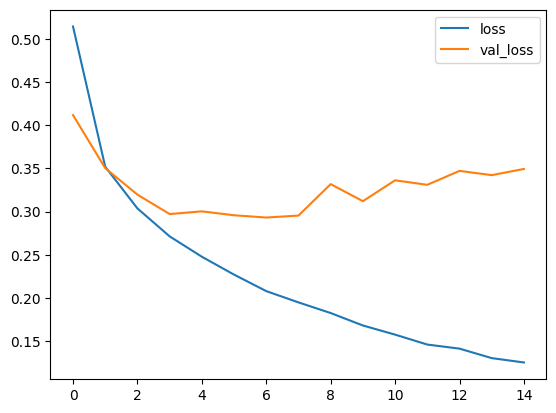

In [21]:
# taxas de perda ou loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

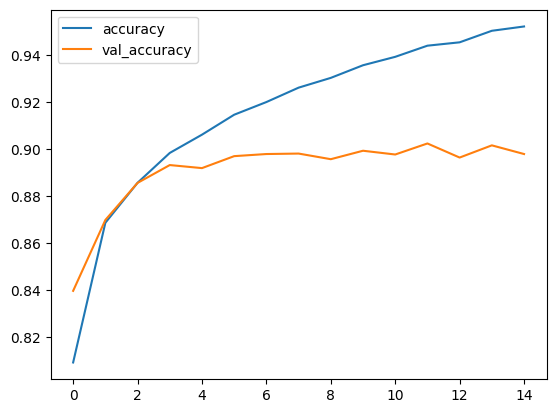

In [22]:
# acuracia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Confusion matrix, without normalization
[[846   2  25  21   3   1  96   0   6   0]
 [  3 974   0  14   5   0   2   0   2   0]
 [ 12   0 817  11  66   0  93   0   1   0]
 [ 12   5  17 899  37   1  29   0   0   0]
 [  0   0  49  23 858   0  69   0   1   0]
 [  0   0   0   1   0 968   0  20   1  10]
 [ 96   0  43  27  99   0 721   0  14   0]
 [  0   0   0   0   0   9   0 974   0  17]
 [  1   0   2   4   6   1   8   4 973   1]
 [  0   0   0   0   0   3   1  46   0 950]]


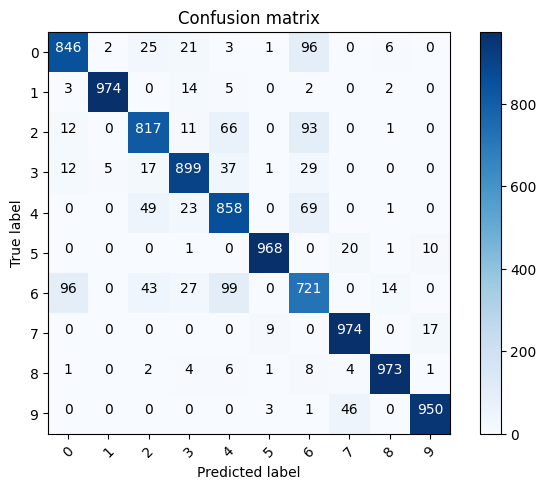

In [23]:
# matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [24]:
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Text(0.5, 1.0, 'True label: Sandal Predicted: Sneaker')

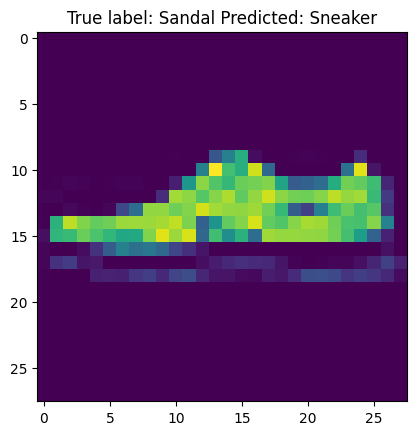

In [26]:
# mostrando imagem classificada incorretamente
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28))
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]))